01_eda_forecasting

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

plt.style.use('dark_background')

STEP 1.2 — LOAD DATA

In [9]:
DATA_PATH = Path("../data/raw/ecommerce_sales.csv")

df = pd.read_csv(
    DATA_PATH,
    sep=';',
    encoding='latin1'
)

df.head()

,ï»¿order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,product_categories,num_product_categories,Status Pesanan,Alasan Pembatalan,Opsi Pengiriman,Metode Pembayaran,Kota/Kabupaten,Provinsi,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Waktu Pesanan Dibuat,source_file
0,ORD_0000001,2,2000,0,0,Celengan,1,Selesai,NaN,Reguler (Cashless)-SPX Standard,Saldo ShopeePay,KOTA SERANG,BANTEN,0,10000,38300,10000,2024-04-01 00:15,AprilSales2024.xlsx
1,ORD_0000002,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA SEMARANG,JAWA TENGAH,0,14500,18576,14500,2024-04-01 01:47,AprilSales2024.xlsx
2,ORD_0000003,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,SeaBank Bayar Instan,KAB. BOGOR,JAWA BARAT,0,8000,7069,8000,2024-04-01 04:25,AprilSales2024.xlsx
3,ORD_0000004,2,400,0,0,Mangkok Sambal / Saus,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA JAMBI,JAMBI,0,20000,32200,20000,2024-04-01 04:41,AprilSales2024.xlsx
4,ORD_0000005,3,3600,0,0,"Keranjang, Other, Tempat Nasi",3,Batal,Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan ...,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA TANGERANG,BANTEN,0,0,0,8000,2024-04-01 06:12,AprilSales2024.xlsx


STEP 1.3 — CEK STRUKTUR DATA

In [10]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20848 entries, 0 to 20847
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   ï»¿order_id                         20848 non-null  object
 1   total_qty                           20848 non-null  int64 
 2   total_weight_gr                     20848 non-null  int64 
 3   total_returned_qty                  20848 non-null  int64 
 4   Total Diskon                        20848 non-null  int64 
 5   product_categories                  20848 non-null  object
 6   num_product_categories              20848 non-null  int64 
 7   Status Pesanan                      20848 non-null  object
 8   Alasan Pembatalan                   2830 non-null   object
 9   Opsi Pengiriman                     20848 non-null  object
 10  Metode Pembayaran                   20848 non-null  object
 11  Kota/Kabupaten                      20848 non-null  ob

,total_qty,total_weight_gr,total_returned_qty,Total Diskon,num_product_categories,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim
count,20848.000000,20848.000000,20848.000000,20848.000000,20848.000000,20848.000000,20848.000000,2.084800e+04,20848.000000
mean,2.560821,2004.529691,0.017748,405.199348,1.112097,4189.990695,10722.539284,5.068360e+04,18425.626343
std,7.796763,7106.357515,0.548656,9784.017705,0.485361,13578.489678,12672.471066,1.440193e+05,23791.508665
min,1.000000,10.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000e+00,1.000000
25%,1.000000,300.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.348000e+04,8000.000000
50%,1.000000,500.000000,0.000000,0.000000,1.000000,0.000000,9500.000000,2.180000e+04,11000.000000
75%,2.000000,1600.000000,0.000000,0.000000,1.000000,3000.000000,15000.000000,4.160000e+04,20000.000000
max,256.000000,375000.000000,70.000000,700000.000000,11.000000,584000.000000,312000.000000,3.403591e+06,959200.000000


STEP 1.4 — CLEANING COLUMN NAME

In [11]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

df.columns

Index(['ï»¿order_id', 'total_qty', 'total_weight_gr', 'total_returned_qty',
       'total_diskon', 'product_categories', 'num_product_categories',
       'status_pesanan', 'alasan_pembatalan', 'opsi_pengiriman',
       'metode_pembayaran', 'kota/kabupaten', 'provinsi',
       'ongkos_kirim_dibayar_oleh_pembeli',
       'estimasi_potongan_biaya_pengiriman', 'total_pembayaran',
       'perkiraan_ongkos_kirim', 'waktu_pesanan_dibuat', 'source_file'],
      dtype='object')

STEP 1.5 — CLEAN DATETIME

In [12]:
df['waktu_pesanan_dibuat'] = pd.to_datetime(
    df['waktu_pesanan_dibuat'],
    errors='coerce'
)

STEP 1.6 — CLEAN REVENUE

CLEAN NUMERIC

In [13]:
df['total_pembayaran'] = (
    df['total_pembayaran']
    .astype(str)
    .str.replace('Rp', '')
    .str.replace('.', '')
    .str.replace(',', '')
    .str.strip()
)

df['total_pembayaran'] = pd.to_numeric(
    df['total_pembayaran'],
    errors='coerce'
)

STEP 1.7 — DROP NULL

In [14]:
df = df.dropna(
    subset=[
        'waktu_pesanan_dibuat',
        'total_pembayaran'
    ]
)

STEP 1.8 — REVENUE TREND ANALYSIS

DAILY REVENUE

In [15]:
daily_sales = df.groupby(
    'waktu_pesanan_dibuat'
)['total_pembayaran'].sum().reset_index()

VISUAL

In [16]:
fig = px.line(
    daily_sales,
    x='waktu_pesanan_dibuat',
    y='total_pembayaran',
    title='Daily Revenue Trend Analysis',
    template='plotly_dark'
)

fig.update_layout(
    paper_bgcolor='#0F172A',
    plot_bgcolor='#0F172A',
    font_color='white',
    title_font_size=26
)

fig.show()

STEP 1.9 — MONTHLY REVENUE

In [17]:
monthly_sales = df.groupby(
    pd.Grouper(
        key='waktu_pesanan_dibuat',
        freq='M'
    )
)['total_pembayaran'].sum().reset_index()

VISUAL

In [18]:
fig = px.bar(
    monthly_sales,
    x='waktu_pesanan_dibuat',
    y='total_pembayaran',
    title='Monthly Revenue Analysis',
    template='plotly_dark',
    color='total_pembayaran'
)

fig.update_layout(
    paper_bgcolor='#0F172A',
    plot_bgcolor='#0F172A',
    font_color='white'
)

fig.show()

STEP 1.10 — TOP PROVINCE ANALYSIS

In [19]:
top_province = df.groupby(
    'provinsi'
)['total_pembayaran'].sum().sort_values(
    ascending=False
).head(10)

VISUAL

In [20]:
fig = px.bar(
    top_province,
    orientation='h',
    title='Top Revenue Provinces',
    template='plotly_dark'
)

fig.update_layout(
    paper_bgcolor='#0F172A',
    plot_bgcolor='#0F172A',
    font_color='white'
)

fig.show()

STEP 1.11 — PAYMENT METHOD ANALYSIS

In [21]:
payment_analysis = df.groupby(
    'metode_pembayaran'
)['total_pembayaran'].sum().sort_values(
    ascending=False
)

VISUAL

In [22]:
fig = px.pie(
    values=payment_analysis.values,
    names=payment_analysis.index,
    hole=0.6,
    title='Payment Method Contribution',
    template='plotly_dark'
)

fig.update_layout(
    paper_bgcolor='#0F172A',
    font_color='white'
)

fig.show()

STEP 1.12 — CANCELLATION ANALYSIS

In [23]:
cancel_analysis = df[
    'status_pesanan'
].value_counts()

VISUAL

In [24]:
fig = px.bar(
    cancel_analysis,
    title='Order Status Analysis',
    template='plotly_dark',
    color=cancel_analysis.values
)

fig.update_layout(
    paper_bgcolor='#0F172A',
    plot_bgcolor='#0F172A',
    font_color='white'
)

fig.show()

STEP 2.1 — INSTALL PROPHET

STEP 2.2 — IMPORT LIBRARY

In [25]:
import pandas as pd
import numpy as np

from prophet import Prophet

import plotly.express as px
import plotly.graph_objects as go

STEP 2.3 — PREPARE FORECASTING DATA

In [26]:
forecast_df = df.groupby(
    'waktu_pesanan_dibuat'
)['total_pembayaran'].sum().reset_index()

PREPARE DATA

In [27]:
forecast_df = df.groupby(
    'waktu_pesanan_dibuat'
)['total_pembayaran'].sum().reset_index()

RENAME COLUMN

In [28]:
forecast_df.columns = ['ds', 'y']

CEK DATA

In [29]:
forecast_df.head()

,ds,y
0,2023-12-01 00:33:00,45200
1,2023-12-01 05:28:00,96445
2,2023-12-01 05:46:00,0
3,2023-12-01 10:01:00,17493
4,2023-12-01 13:19:00,32925


STEP 2.4 — TRAIN MODEL

In [30]:
model = Prophet(
    daily_seasonality=True,
    yearly_seasonality=True,
    weekly_seasonality=True
)

model.fit(forecast_df)

23:16:31 - cmdstanpy - INFO - Chain [1] start processing
23:16:34 - cmdstanpy - INFO - Chain [1] done processing


STEP 2.5 — CREATE FUTURE DATA

In [31]:
future = model.make_future_dataframe(
    periods=30
)

STEP 2.6 — PREDICT

In [32]:
forecast = model.predict(future)

CEK HASIL

In [33]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2023-12-01 00:33:00,56467.383932,-147917.123814,234613.041587,56467.383932,56467.383932,-14162.793732,-14162.793732,-14162.793732,-5059.526267,...,-5306.569941,-5306.569941,-5306.569941,-3796.697524,-3796.697524,-3796.697524,0.0,0.0,0.0,42304.590200
1,2023-12-01 05:28:00,56460.789335,-148597.710703,213232.220117,56460.789335,56460.789335,-21426.429264,-21426.429264,-21426.429264,-14587.158705,...,-2911.036404,-2911.036404,-2911.036404,-3928.234155,-3928.234155,-3928.234155,0.0,0.0,0.0,35034.360071
2,2023-12-01 05:46:00,56460.386952,-142833.064460,219967.510718,56460.386952,56460.386952,-19417.104673,-19417.104673,-19417.104673,-12743.961885,...,-2736.865670,-2736.865670,-2736.865670,-3936.277117,-3936.277117,-3936.277117,0.0,0.0,0.0,37043.282280
3,2023-12-01 10:01:00,56454.686538,-124320.143902,254117.708203,56454.686538,56454.686538,10481.299295,10481.299295,10481.299295,14693.016491,...,-161.302059,-161.302059,-161.302059,-4050.415136,-4050.415136,-4050.415136,0.0,0.0,0.0,66935.985833
4,2023-12-01 13:19:00,56450.260333,-120441.751029,251318.628393,56450.260333,56450.260333,7398.639720,7398.639720,7398.639720,9827.246060,...,1710.671024,1710.671024,1710.671024,-4139.277365,-4139.277365,-4139.277365,0.0,0.0,0.0,63848.900053


STEP 2.7 — VISUAL FORECASTING

In [34]:
fig = go.Figure()

# actual revenue

fig.add_trace(go.Scatter(
    x=forecast_df['ds'],
    y=forecast_df['y'],
    mode='lines',
    name='Actual Revenue'
))

# forecast

fig.add_trace(go.Scatter(
    x=forecast['ds'],
    y=forecast['yhat'],
    mode='lines',
    name='Forecast Revenue'
))

# upper confidence

fig.add_trace(go.Scatter(
    x=forecast['ds'],
    y=forecast['yhat_upper'],
    mode='lines',
    line=dict(width=0),
    showlegend=False
))

# lower confidence

fig.add_trace(go.Scatter(
    x=forecast['ds'],
    y=forecast['yhat_lower'],
    mode='lines',
    fill='tonexty',
    line=dict(width=0),
    name='Confidence Interval'
))

fig.update_layout(
    title='AI Revenue Forecasting Analysis',
    template='plotly_dark',
    paper_bgcolor='#0F172A',
    plot_bgcolor='#0F172A',
    font_color='white',
    title_font_size=26
)

fig.show()

STEP 2.8 — FORECAST COMPONENT ANALYSIS

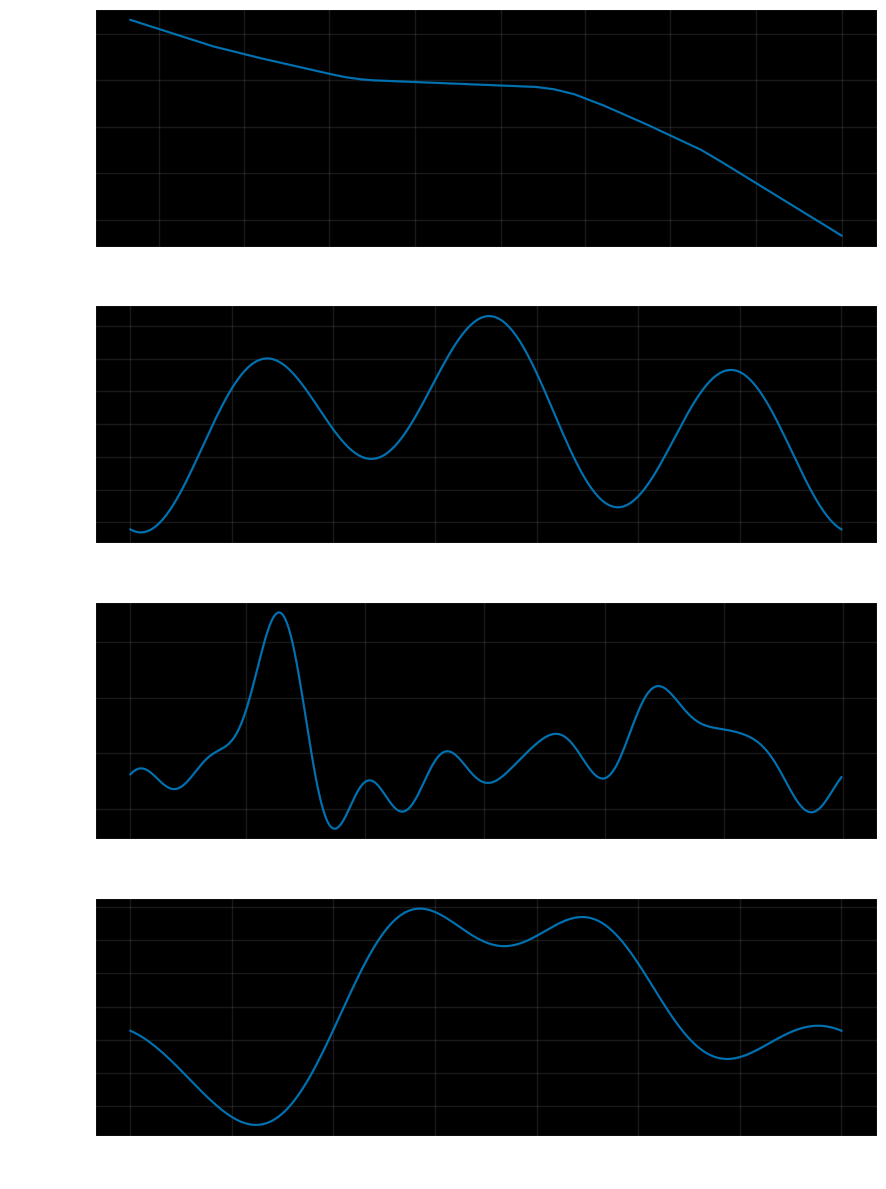

In [35]:
fig2 = model.plot_components(
    forecast
)

STEP 2.9 — FUTURE REVENUE SUMMARY

In [36]:
future_30 = forecast.tail(30)

future_revenue = future_30['yhat'].sum()

print(f"""
Predicted Revenue Next 30 Days:
Rp {future_revenue:,.0f}
""")


Predicted Revenue Next 30 Days:
Rp 698,576



STEP 2.10 — FORECASTING INSIGHT

In [37]:
print("""
Business Insight:
- Revenue trend shows stable growth pattern
- Weekly seasonality indicates peak transaction periods
- Forecast suggests increasing revenue potential
- Business should prepare inventory scaling strategy
""")


Business Insight:
- Revenue trend shows stable growth pattern
- Weekly seasonality indicates peak transaction periods
- Forecast suggests increasing revenue potential
- Business should prepare inventory scaling strategy



STEP 3.1 — IMPORT LIBRARY

In [38]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import zscore

STEP 3.2 — PREPARE DAILY SALES

In [39]:
daily_sales = df.groupby(
    'waktu_pesanan_dibuat'
)['total_pembayaran'].sum().reset_index()

RENAME COLUMN

In [40]:
daily_sales.columns = [
    'date',
    'revenue'
]

STEP 3.3 — HITUNG Z-SCORE

In [41]:
daily_sales['z_score'] = zscore(
    daily_sales['revenue']
)

STEP 3.4 — DETEKSI ANOMALY

In [43]:
daily_sales['anomaly'] = np.where(
    abs(daily_sales['z_score']) > 3,
    'Anomaly',
    'Normal'
)

CEK HASIL

In [44]:
daily_sales.head()

,date,revenue,z_score,anomaly
0,2023-12-01 00:33:00,45200,-0.044349,Normal
1,2023-12-01 05:28:00,96445,0.311794,Normal
2,2023-12-01 05:46:00,0,-0.358480,Normal
3,2023-12-01 10:01:00,17493,-0.236907,Normal
4,2023-12-01 13:19:00,32925,-0.129658,Normal


STEP 3.5 — VISUAL

In [45]:
fig = px.scatter(
    daily_sales,
    x='date',
    y='revenue',
    color='anomaly',
    title='Revenue Anomaly Detection Analysis',
    template='plotly_dark',
    color_discrete_map={
        'Normal': '#22C55E',
        'Anomaly': '#EF4444'
    }
)

fig.update_layout(
    paper_bgcolor='#0F172A',
    plot_bgcolor='#0F172A',
    font_color='white',
    title_font_size=26
)

fig.show()

STEP 3.6 — TOP ANOMALY DAY

In [46]:
anomaly_days = daily_sales[
    daily_sales['anomaly'] == 'Anomaly'
]

TAMPILKAN

In [47]:
anomaly_days.sort_values(
    by='revenue',
    ascending=False
).head()

,date,revenue,z_score,anomaly
6573,2024-09-14 06:48:00,3076000,21.019117,Anomaly
10680,2025-02-05 09:59:00,3023425,20.653731,Anomaly
4288,2024-07-21 08:35:00,2889700,19.724369,Anomaly
16608,2025-10-08 15:16:00,2884000,19.684755,Anomaly
14356,2025-08-04 13:34:00,2756000,18.795180,Anomaly


STEP 3.7 — BUSINESS INSIGHT

In [48]:
print("""
Business Intelligence Insight:
- Revenue anomalies indicate unusual transaction spikes
- Potential causes include flash sales, promotions, or seasonal campaigns
- Sudden revenue drops may indicate operational issues or reduced customer activity
- Monitoring anomalies helps businesses respond faster to unusual market behavior
""")


Business Intelligence Insight:
- Revenue anomalies indicate unusual transaction spikes
- Potential causes include flash sales, promotions, or seasonal campaigns
- Sudden revenue drops may indicate operational issues or reduced customer activity
- Monitoring anomalies helps businesses respond faster to unusual market behavior



STEP 3.8 — KPI SUMMARY

In [49]:
total_revenue = daily_sales[
    'revenue'
].sum()

avg_daily_revenue = daily_sales[
    'revenue'
].mean()

anomaly_count = len(
    anomaly_days
)

print(f"""
EXECUTIVE SUMMARY
-------------------------
Total Revenue      : Rp {total_revenue:,.0f}
Average Daily Rev  : Rp {avg_daily_revenue:,.0f}
Detected Anomalies : {anomaly_count}
""")


EXECUTIVE SUMMARY
-------------------------
Total Revenue      : Rp 958,948,812
Average Daily Rev  : Rp 51,581
Detected Anomalies : 214

